# 01-3. 생선 이름을 자동으로 알려 주는 머신 러닝 프로그램

한빛 마켓에서 팔기 시작한 생선은 '도미', '곤들매기', '농어', '강꼬치고기', '로치', '빙어', '송어'

이 생선들을 프로그램으로 분류하는 게 목적!

---

## 1. 데이터 준비하기

### 1.1. 도미 데이터 준비하기

- 생선 길이가 30cm 이상이면 도미일 확률이 높은 것이지, 30cm보다 큰 생선이 무조건 도미라고 말할 수 없음
- 반대로 도미의 크기가 모두 같을 리도 없음
- 따라서 머신러닝은 여러 개의 도미 생선을 보면서 스스로 어떤 생선이 도미인지 구분할 기준을 찾음 (이때, 무게와 길이를 함께 측정)
- 각 도미의 특징을 길이와 무게로 표현한 것을 특성이라고 부름

In [1]:
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

### 1.2. 산점도 그래프 출력하기

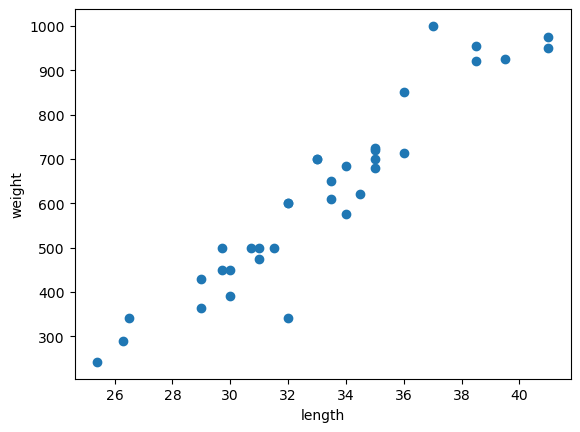

In [2]:
import matplotlib.pyplot as plt

plt.scatter(bream_length, bream_weight)
plt.xlabel('length')    # x축 라벨 이름 지정
plt.ylabel('weight')    # y축 라벨 이름 지정
plt.show()              # 준비된 그래프를 화면에 출력

- 2개의 특성을 사용해 그린 그래프이기 때문에 2차원 그래프
- 산점도 그래프가 일직선에 가까운 형태로 나타나는 경우를 선형적 (Linear)

### 1.3. 방어 데이터 준비하기

In [3]:
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

### 1.4. 산점도 그래프 출력하기

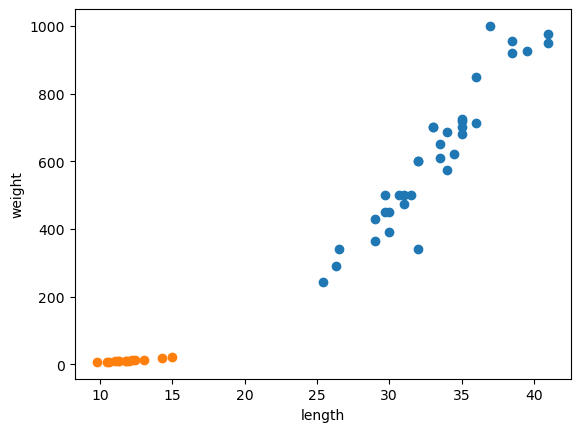

In [4]:
import matplotlib.pyplot as plt

plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

- `scatter()` 함수를 연달아 사용하면 2개의 산점도를 함께 한 그래프로 그릴 수 있음


#### ∴ 빙어의 산점도도 선형적이지만 무게가 길이의 영향을 덜 받음

---

## 2. 머신 러닝

- KNN(K-최근접 이웃: K-NEarest Neighbors) 알고리즘 사용

### 2.1. 데이터 준비하기

In [5]:
# 앞서 준비했던 도미 데이터, 빙어 데이터를 하나의 데이터로 합치기 위해 두 리스트를 더해서 하나의 리스트로 만들어 줌

length = bream_length + smelt_length
weight = bream_weight + smelt_weight

- scikit-learn 패키지를 사용하려면 2차원의 리스트가 필요함
- 2차원 리스트를 만드는 방법으로는 파이썬의 `zip` 함수나 List Comprehension 구문을 사용해야 함

In [6]:
fish_data = [[I, w] for I, w in zip(length, weight)]
print(fish_data)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]


- 도미와 빙어를 구분하는 규칙을 찾아야 하는데, 그러려면 적어도 어떤 생선이 도미인지 빙어인지 알려 주어야 함
- 현재 샘플 데이터에서 도미가 35마리, 빙어가 14마리이므로 도미와 빙어를 각각 1과 0으로 나타내어 정답 데이터 리스트를 생성함
    - 이진 분류에서 1을 양성 클래스(positive class), 0을 음성 클래스(negative class)라고 부름

In [7]:
fish_target = [1] * 35 + [0] * 14
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### 2.2. 패키지 임포트

In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [9]:
import sklearn
model = sklearn.neighbors.KNeighborsClassifier()

In [10]:
# 임포트한 KNeighborsClassifier 클래스의 객체
kn = KNeighborsClassifier()

### 2.3. 훈련(Training)

- 객체에 `fish_data`와 `fish_target`을 전달하여 도미를 찾기 위한 기준을 학습시킴 => 훈련(Training)
- scikit-learn의 `fit()` 메서드는 주어진 데이터로 알고리즘을 훈련함

In [11]:
kn.fit(fish_data, fish_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 2.4. 모델 평가

- 객체 또는 모델이 얼마나 잘 훈련되어 있는지 평가하기 위해 `score()` 메서드를 사용함
    - 0에서 1 사이의 정확도 값을 반환하는데, 이때 1은 모든 데이터를 정확하게 맞혔다는 뜻

In [12]:
kn.score(fish_data, fish_target)

1.0

---

## 3. KNN(K-최근접 이웃: K-NEarest Neighbors) 알고리즘

=> 어떤 데이터에 대한 답을 구할 때 주위의 다른 데이터를 보고 다수를 차지하는 것을 정답으로 사용함

### 3.1. 산점도 그래프 기준
- 아래의 산점도 그래프에서 삼각형 기호 주변에 다른 도미 데이터가 많기 때문에 도미라고 판단함

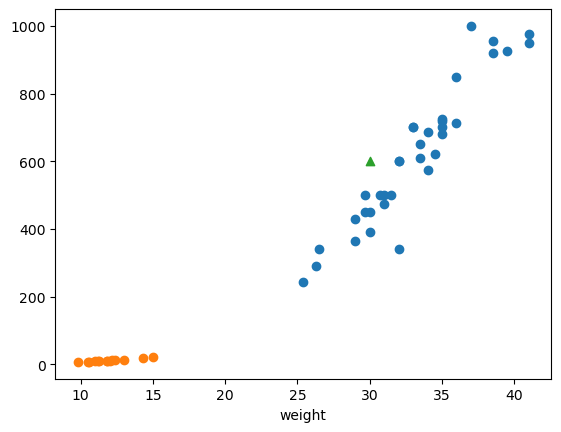

In [13]:
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
plt.scatter(30, 600, marker = '^')

plt.xlabel('length')
plt.xlabel('weight')
plt.show()

### 3.2. `predict()` 메서드

- `predict()` 메서드는 새로운 데이터의 정답을 예측함
- 리스트의 리스트 안의 1이므로 예상한 것과 같은 '도미'라는 값을 반환함

In [14]:
kn.predict([[30, 600]])

array([1])

### 3.3. `_fit_X` 속성
- `fish_data`를 모두 가지고 있음

In [15]:
print(kn._fit_X)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


### 3.4. `_y` 속성
- `fish_target`를 모두 가지고 있음

In [16]:
print(kn._y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0]


### 3.5. `n_neighbors` 매개변수

- `n_neighbors = k` : 새로운 데이터를 분류할 때 가장 가까운 `k`개의 이웃을 참고한다는 의미
- 즉, `k = 49`로 할 경우, 가장 가까운 49개의 이웃을 참고하여 그중 다수결로 클래스를 결정

In [17]:
kn49 = KNeighborsClassifier(n_neighbors = 49)

In [18]:
kn49.fit(fish_data, fish_target)
kn49.score(fish_data, fish_target)

0.7142857142857143

- `fish_data`에 총 49개 샘플이 있고 그 중 35개가 도미(1), 14개가 빙어(0)라면 새로운 데이터는 항상 다수결로 도미(1)로 분류됨
- 즉, `kn49` 모델은 도미만 올바르게 맞히기 때문에 위와 같은 값을 얻을 수 있음

#### (+) k값 선택의 중요성:

- k가 너무 작으면: 노이즈에 민감 (overfitting)
- k가 너무 크면: 경계가 너무 단순해짐 (underfitting)
- 보통 홀수를 사용 (동점 방지)

---

## 4. 확인 문제: 5번

In [19]:
kn_test = KNeighborsClassifier()
kn_test.fit(fish_data, fish_target)
for n in range(5, 50):
    # k-최근접 이웃 개수 설정
    kn_test.n_neighbors = n
    # 점수 계산
    score = kn_test.score(fish_data, fish_target)
    # 100% 정확도에 미치지 못하는 이웃 개수 출력
    if score < 1:
        print(n, score)
        break

18 0.9795918367346939
